In [21]:
import pandas as pd
df = pd.read_csv("sales_data_analysis.csv")
df.head()

,Order_ID,Order_Date,City,Product,Category,Quantity,Unit_Price,Discount,Sales
0,1,2026-03-04,Bengaluru,Smartphone,Electronics,1,25000,0.10,22500.0
1,2,2026-06-01,Mumbai,Headphones,Accessories,1,2500,0.00,2500.0
2,3,2026-02-25,Bengaluru,Laptop,Electronics,1,55000,0.00,55000.0
3,4,2026-06-16,Pune,Laptop,Electronics,5,55000,0.05,261250.0
4,5,2026-05-31,Chennai,Tablet,Electronics,2,18000,0.15,30600.0


In [2]:
df.shape

(100, 9)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order_ID    100 non-null    int64  
 1   Order_Date  100 non-null    str    
 2   City        100 non-null    str    
 3   Product     100 non-null    str    
 4   Category    100 non-null    str    
 5   Quantity    100 non-null    int64  
 6   Unit_Price  100 non-null    int64  
 7   Discount    100 non-null    float64
 8   Sales       100 non-null    float64
dtypes: float64(2), int64(3), str(4)
memory usage: 10.6 KB


In [4]:
df.isnull().sum()

Order_ID      0
Order_Date    0
City          0
Product       0
Category      0
Quantity      0
Unit_Price    0
Discount      0
Sales         0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,Order_ID,Quantity,Unit_Price,Discount,Sales
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,2.930000,16333.000000,0.080500,44585.800000
std,29.011492,1.505914,17782.877106,0.052654,61414.518974
min,1.000000,1.000000,900.000000,0.000000,765.000000
25%,25.750000,2.000000,2500.000000,0.050000,6592.500000
50%,50.500000,3.000000,12000.000000,0.100000,18750.000000
75%,75.250000,4.000000,25000.000000,0.100000,64687.500000
max,100.000000,5.000000,55000.000000,0.150000,275000.000000


In [9]:
df.groupby("City")["Sales"].sum().sort_values(ascending=False)

City
Hyderabad    1274255.0
Bengaluru     995450.0
Pune          788655.0
Delhi         501020.0
Chennai       483535.0
Mumbai        415665.0
Name: Sales, dtype: float64

In [11]:
df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

Product
Laptop        2241250.0
Smartphone     960000.0
Tablet         565200.0
Monitor        343800.0
Smartwatch     150000.0
Headphones     111750.0
Keyboard        62910.0
Mouse           23670.0
Name: Sales, dtype: float64

In [13]:
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Electronics    4110250.0
Accessories     198330.0
Wearables       150000.0
Name: Sales, dtype: float64

Matplotlib is building the font cache; this may take a moment.


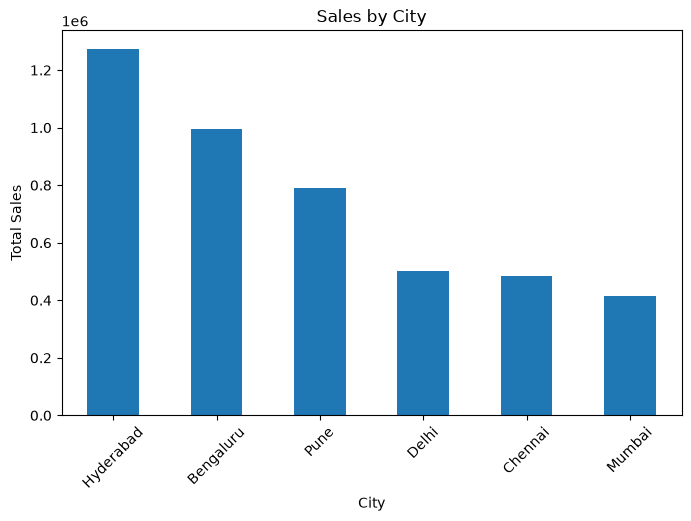

In [14]:
import matplotlib.pyplot as plt
city_sales = df.groupby("City")["Sales"].sum().sort_values(ascending=False)
city_sales.plot(kind="bar",figsize=(8,5))
plt.title("Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

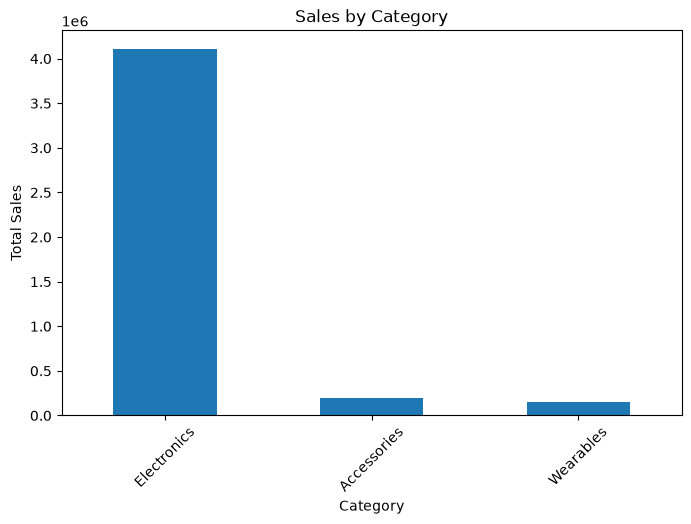

In [15]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
category_sales.plot(kind="bar",figsize=(8,5))
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

df["Order_Date"] = pd.to_datetime(df["Order_Date"])

monthly_sales = df.groupby(df["Order_Date"].dt.to_period("M"))["Sales"].sum()

monthly_sales.plot(kind="line", marker="o", figsize=(8,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [18]:
top_products = df.groupby("Product")["Sales"].sum().sort_values(ascending=False).head(5)
print(top_products)

Product
Laptop        2241250.0
Smartphone     960000.0
Tablet         565200.0
Monitor        343800.0
Smartwatch     150000.0
Name: Sales, dtype: float64


In [19]:
print("Total Sales:", df["Sales"].sum())
print("Total Orders:", df["Order_ID"].count())
print("Total Quantity Sold:", df["Quantity"].sum())
print("Average Order Value:", df["Sales"].mean())

Total Sales: 4458580.0
Total Orders: 100
Total Quantity Sold: 293
Average Order Value: 44585.8


In [20]:
print("KEY INSIGHTS")
print("--------------------")
print("1. Total sales generated:", df["Sales"].sum())
print("2. Total orders:", df["Order_ID"].count())
print("3. Total quantity sold:", df["Quantity"].sum())
print("4. Average order value:", round(df["Sales"].mean(), 2))

print("\nTop City by Sales:")
print(df.groupby("City")["Sales"].sum().idxmax())

print("\nTop Product by Sales:")
print(df.groupby("Product")["Sales"].sum().idxmax())

print("\nTop Category by Sales:")
print(df.groupby("Category")["Sales"].sum().idxmax())

KEY INSIGHTS
--------------------
1. Total sales generated: 4458580.0
2. Total orders: 100
3. Total quantity sold: 293
4. Average order value: 44585.8

Top City by Sales:
Hyderabad

Top Product by Sales:
Laptop

Top Category by Sales:
Electronics


# Sales Data Analysis Using Python

## Project Overview

This project analyzes sales data using Python and Pandas.
The analysis focuses on sales performance by city, product, category, and month.

## Tools Used

- Python
- Pandas
- Matplotlib
- Jupyter Notebook